# Configuration

In [1]:
# --- CONFIGURATION & HYPERPARAMETERS ---
CFG = {
    'model_name': 'CNN_LSTM_KLD_v0', #assigning a consistent name for the model

    # Data Settings
    'subset_frac': 0.10,      # Train on 10% for fast debugging
    'img_size': (128, 256),  # (Freq, Time)
    'seed': None,              # For reproducibility (or None for randomness)

    # Model Architecture
    'hidden_size': 256,      # LSTM hidden units
    'dropout': 0.2,          # Regularization

    # Training Loop
    'epochs': 5,            # Default 25
    'batch_size': 128,
    'lr': 1e-3,              # Learning Rate
    'weight_decay': 1e-2,

    # Paths
    'train_csv': '/content/drive/MyDrive/Seneca/Capstone/spectrograms/train.csv',
    'val_csv': '/content/drive/MyDrive/Seneca/Capstone/spectrograms/val.csv',
    'train_dir': '/content/train_spectrograms',
    'val_dir': '/content/val_spectrograms'
}

print(f"Configuration Loaded. Mode: {'Debug (Subset)' if CFG['subset_frac'] < 1 else 'Full Training'}")

Configuration Loaded. Mode: Debug (Subset)


# Loading the Data and Preprocessing

In [2]:
# 1. Install the specific library for the CNN backbone
!pip install -q timm

# 2. Connect to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Verify you can see your files (Change path if needed)
import os
# Check if your folder exists
if os.path.exists('/content/drive/MyDrive/Seneca/Capstone/spectrograms'):
    print("Success! Connected to Capstone Data.")
else:
    print("Warning: Folder not found. Check your path in Drive.")

Mounted at /content/drive
Success! Connected to Capstone Data.


In [3]:
!ls /content/

drive  sample_data


In [4]:
import shutil

# Define paths
zip_path = '/content/drive/MyDrive/Seneca/Capstone/spectrograms/train_spectrograms.zip'
local_dir = '/content/train_spectrograms'

print("Copying data to local machine (this speeds up training)...")
# Unzip directly to local folder
shutil.unpack_archive(zip_path, local_dir)

print("Done! Data is ready for the model.")

Copying data to local machine (this speeds up training)...
Done! Data is ready for the model.


In [5]:
# Unzip the Validation Spectrograms
val_zip_path = '/content/drive/MyDrive/Seneca/Capstone/spectrograms/val_spectrograms.zip'
val_local_dir = '/content/val_spectrograms'

print("Unzipping validation data...")
shutil.unpack_archive(val_zip_path, val_local_dir)
print("Done! Validation data ready.")

Unzipping validation data...
Done! Validation data ready.


In [6]:
import pandas as pd
import torch
import numpy as np
import cv2
from torch.utils.data import Dataset

class HMSDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.data = df #Changed from 'pd.read_csv(csv_file)' to control train and val set sizes
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        spec_id = row['spectrogram_id']
        img_path = f"{self.img_dir}/{spec_id}.parquet"

        try:
            # Load data (Time is usually the index, Frequency is columns)
            # Shape: (Time_Steps, Frequencies) e.g., (4000, 400)
            spectrogram = pd.read_parquet(img_path).values
        except Exception as e:
            return torch.zeros((1, 128, 256)), torch.zeros(6)

        # 1. Handle NaNs and Log Scale
        spectrogram = np.nan_to_num(spectrogram)
        spectrogram = np.log1p(spectrogram)

        # 2. THE FIX: CENTER CROP (Time Dimension)
        # We want a fixed time window of 256 steps.
        # If the file is 4000 steps long, we take the middle 256.
        # If it's too short, we pad it.

        desired_time = 256
        current_time = spectrogram.shape[0] # The variable length (e.g. 337 or 4089)

        if current_time > desired_time:
            # Crop the center
            start = (current_time - desired_time) // 2
            spectrogram = spectrogram[start : start + desired_time, :]
        else:
            # Pad with zeros if too short
            pad_needed = desired_time - current_time
            # Pad (Bottom, Top) -> (Time_End, Time_Start)
            spectrogram = np.pad(spectrogram, ((0, pad_needed), (0, 0)), mode='constant')

        # 3. Resize Frequency (Height) only
        # We can safely squish frequency (e.g. 400 -> 128) without losing the "event"
        # cv2.resize takes (Width, Height) -> (Frequency, Time)
        # We want output (256, 128) -> Time=256, Freq=128
        spectrogram = cv2.resize(spectrogram, (128, 256))

        # 4. Standardize
        mean = spectrogram.mean()
        std = spectrogram.std() + 1e-6
        spectrogram = (spectrogram - mean) / std

        # 5. Final Shape: (Channels, Time, Freq) -> (1, 256, 128)
        # We need to Transpose so Time is the width?
        # Actually EfficientNet expects (C, H, W). Let's treat Time as Width.
        spectrogram = spectrogram.T # Now (128, 256) -> (Freq, Time)
        spectrogram = torch.tensor(spectrogram, dtype=torch.float32).unsqueeze(0)

        # Labels
        label_cols = ['seizure_vote', 'lpd_vote', 'gpd_vote', 'lrda_vote', 'grda_vote', 'other_vote']
        labels = row[label_cols].values.astype('float32')
        labels = labels / (labels.sum() + 1e-6)

        return spectrogram, torch.tensor(labels, dtype=torch.float32)



---



# CNN-LSTM Hybrid

In [7]:
import torch
import torch.nn as nn
import timm

class HybridLSTMSpectrogramModel(nn.Module):
    def __init__(self, num_classes=6, hidden_size=256, num_layers=2):
        super().__init__()

        # 1. The CNN Backbone (Same as Transformer version)
        self.cnn = timm.create_model(
            'efficientnet_b0',
            pretrained=True,
            in_chans=1,
            features_only=True,
            out_indices=[4] # Deepest block = 320 channels
        )

        cnn_out_channels = 320

        # 2. The LSTM Layer
        # Note: We don't need a projection layer here because we can just
        # tell the LSTM that the input_size is 320.
        self.lstm = nn.LSTM(
            input_size=cnn_out_channels,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True # Bidirectional helps it see past AND future
        )

        # 3. Classifier
        # If bidirectional, the output size is hidden_size * 2
        self.classifier = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # x shape: (Batch, 1, 128, 256)

        # 1. Extract Features via CNN
        features = self.cnn(x)[0] # Shape: (Batch, 320, H, W)

        # 2. Prepare for LSTM (Spatial -> Sequence)
        # Pool the Frequency (Height), leave Time (Width)
        features = features.mean(dim=2) # Shape: (Batch, 320, Time)

        # Permute to (Batch, Time, Features) for LSTM
        features = features.permute(0, 2, 1) # Shape: (Batch, Time, 320)

        # 3. LSTM Processing
        # output shape: (Batch, Time, hidden_size*2)
        # _ represents hidden states we don't need right now
        lstm_out, _ = self.lstm(features)

        # 4. Global Average Pooling
        # We take the average of all time steps to summarize the clip
        x = lstm_out.mean(dim=1)

        # 5. Classify
        output = self.classifier(x)
        return output

In [8]:
from torch.utils.data import DataLoader
"""
#Old code b4 config cell
# --- 1. Define where your files are (on the Colab machine) ---
# You unzipped the folders here:
TRAIN_IMG_DIR = '/content/train_spectrograms'
VAL_IMG_DIR   = '/content/val_spectrograms'

# You have the CSVs here (uploaded to Colab or Drive):
TRAIN_CSV = '/content/drive/MyDrive/Seneca/Capstone/spectrograms/train.csv'
VAL_CSV   = '/content/drive/MyDrive/Seneca/Capstone/spectrograms/val.csv'

#New: Converting TRAIN/VAL_CSV to df and sampling a fraction of the sets
frac = 0.2 #20% of the total train/val sets
TRAIN_CSV = pd.read_csv(TRAIN_CSV)
TRAIN_CSV = TRAIN_CSV.sample(frac=frac)

VAL_CSV = pd.read_csv(VAL_CSV)
VAL_CSV = VAL_CSV.sample(frac=frac)

# --- 2. Create the Datasets ---
# HERE is where we pass the specific CSV file!
train_dataset = HMSDataset(df=TRAIN_CSV, img_dir=TRAIN_IMG_DIR)
val_dataset   = HMSDataset(df=VAL_CSV,   img_dir=VAL_IMG_DIR)

print(f"--- Data Ready ---")
print(f"Training on {len(train_dataset)} samples ({frac*100}% of total)")
print(f"Validating on {len(val_dataset)} samples ({frac*100}% of total)")
"""
# Use CFG for everything
full_train_df = pd.read_csv(CFG['train_csv'])
full_val_df   = pd.read_csv(CFG['val_csv'])

# Apply subset fraction from CFG
train_subset = full_train_df.sample(frac=CFG['subset_frac'], random_state=CFG['seed']).reset_index(drop=True)
val_subset   = full_val_df.sample(frac=CFG['subset_frac'], random_state=CFG['seed']).reset_index(drop=True)

train_dataset = HMSDataset(df=train_subset, img_dir=CFG['train_dir'])
val_dataset   = HMSDataset(df=val_subset,   img_dir=CFG['val_dir'])

#train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'], shuffle=True)
train_loader = DataLoader(
    train_dataset,
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=4,      # Try 2 or 4 (Colab T4 usually has 2 cores)
    pin_memory=True     # Speeds up the transfer from CPU to GPU
)
#val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'], shuffle=False)
val_loader = DataLoader(
    val_dataset,
    batch_size=CFG['batch_size'],
    shuffle=False,
    num_workers=4,      # Try 2 or 4 (Colab T4 usually has 2 cores)
    pin_memory=True     # Speeds up the transfer from CPU to GPU
)

print(f"--- Data Ready ---")
print(f"Training on {len(train_dataset)} samples ({CFG['subset_frac']*100}% of total)")
print(f"Validating on {len(val_dataset)} samples ({CFG['subset_frac']*100}% of total)")

--- Data Ready ---
Training on 8544 samples (10.0% of total)
Validating on 1068 samples (10.0% of total)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()




---



# Training begins

In [9]:
import torch.optim as optim

# 1. Define the Device (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

"""
#Old code b4 config cell
# Initialize the LSTM Model
# hidden_size=256 matches the d_model=256 of your Transformer for a fair fight
model = HybridLSTMSpectrogramModel(num_classes=6, hidden_size=256)

# Send to GPU
model = model.to(device)

# Reset the Optimizer (Crucial! The old optimizer is attached to the old model)
# Define the Optimizer (The Teacher's Feedback)
# AdamW is the standard "smart" optimizer
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
"""
model = HybridLSTMSpectrogramModel(
    num_classes=6,
    hidden_size=CFG['hidden_size'] # Use CFG
)
model = model.to(device)

optimizer = optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],                  # Use CFG
    weight_decay=CFG['weight_decay'] # Use CFG
)

# 4. Define the Loss Function (The Grading Scale)
# KL Divergence expects the model to output log-probabilities
# and the targets to be probabilities.
loss_fn = nn.KLDivLoss(reduction='batchmean')

print("LSTM Model Loaded and Ready.")

Training on: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

LSTM Model Loaded and Ready.


In [10]:
from tqdm import tqdm # This creates a nice progress bar

scaler = torch.amp.GradScaler('cuda') # Initialize once at the top of the cell

def train_one_epoch(dataloader, model, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    progress_bar = tqdm(dataloader, desc="Training", leave=False)

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(): # Wraps the forward pass
            outputs = model(inputs)
            # Convert raw outputs (logits) to log-probabilities
            log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
            # Calculate loss using log_probs instead of raw outputs
            loss = loss_fn(log_probs, targets)

        scaler.scale(loss).backward() # Scaled backward pass
        scaler.step(optimizer)
        scaler.update()

        # --- INSERT UNIVERSAL ACCURACY LOGIC HERE ---
        _, predicted = torch.max(outputs, 1)        # The model's favorite choice
        _, true_labels = torch.max(targets, 1)      # The doctors' favorite choice

        correct_preds += (predicted == true_labels).sum().item()
        total_samples += targets.size(0)
        # --------------------------------------------

        running_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = correct_preds / total_samples
    return epoch_loss, epoch_acc

def validate_one_epoch(dataloader, model, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, targets in tqdm(dataloader, desc="Validating", leave=False):
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            # Apply log_softmax for KLD calculation
            log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
            loss = loss_fn(log_probs, targets)

            # --- INSERT UNIVERSAL ACCURACY LOGIC HERE ---
            _, predicted = torch.max(outputs, 1)
            _, true_labels = torch.max(targets, 1)

            correct_preds += (predicted == true_labels).sum().item()
            total_samples += targets.size(0)
            # --------------------------------------------

            running_loss += loss.item()

    avg_loss = running_loss / len(dataloader)
    avg_acc = correct_preds / total_samples
    return avg_loss, avg_acc

In [11]:
import time

# --- Configuration ---
#NUM_EPOCHS = 10             # How many times to study the whole dataset
best_val_loss = float('inf') # Track the best score to save the best model
history = history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    } # To plot a graph later
#model_name = 'CNN_LSTM_epoch20' #name of the model

print(f"Starting training for {CFG['epochs']} epochs on {device}...")
start_time = time.time()

"""
#Old code b4 config cell
for epoch in range(NUM_EPOCHS):
    # --- 1. Train (The Model Studies) ---
    # Note: We use the function definitions I gave you earlier
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer, device)

    # --- 2. Validate (The Model Takes a Quiz) ---
    val_loss = validate_one_epoch(val_loader, model, loss_fn, device)
"""
# Use CFG for the loop range
for epoch in range(CFG['epochs']):
    """
    train_loss = train_one_epoch(train_loader, model, loss_fn, optimizer, device)
    val_loss = validate_one_epoch(val_loader, model, loss_fn, device)
    # ... rest of your logging ...

    # --- 3. Record History ---
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    """
    # Inside Cell 9's loop:
    train_loss, train_acc = train_one_epoch(train_loader, model, loss_fn, optimizer, device)
    val_loss, val_acc = validate_one_epoch(val_loader, model, loss_fn, device)

    # Save both to your history for plotting
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # --- 4. Print Progress ---
    # We print a clean line so you can see if it's improving
    #print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"Epoch {epoch+1}/{CFG['epochs']} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    # --- 5. Save the "Best" Version ---
    # If the model scored better on the quiz than ever before, save it!
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        #torch.save(model.state_dict(), "best_transformer_model.pth") #Old code b4 config cell
        torch.save(model.state_dict(), CFG['model_name'] + '.pth')
        print(f"  --> New best model saved! (Loss: {val_loss:.4f})")

total_time = time.time() - start_time
print(f"\nTraining Complete in {total_time/60:.2f} minutes!")

Starting training for 5 epochs on cuda...


Training:   0%|          | 0/67 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/tmp/ipykernel_288/234038694.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(): # Wraps the forward pass


Epoch 1/5 | Train Loss: 0.6957 | Val Loss: 0.8791
  --> New best model saved! (Loss: 0.8791)


Epoch 2/5 | Train Loss: 0.4124 | Val Loss: 0.9905


Epoch 3/5 | Train Loss: 0.3051 | Val Loss: 0.8872


Epoch 4/5 | Train Loss: 0.2453 | Val Loss: 1.0352


Epoch 5/5 | Train Loss: 0.2339 | Val Loss: 0.9419

Training Complete in 31.22 minutes!


# Training Curve and Metrics

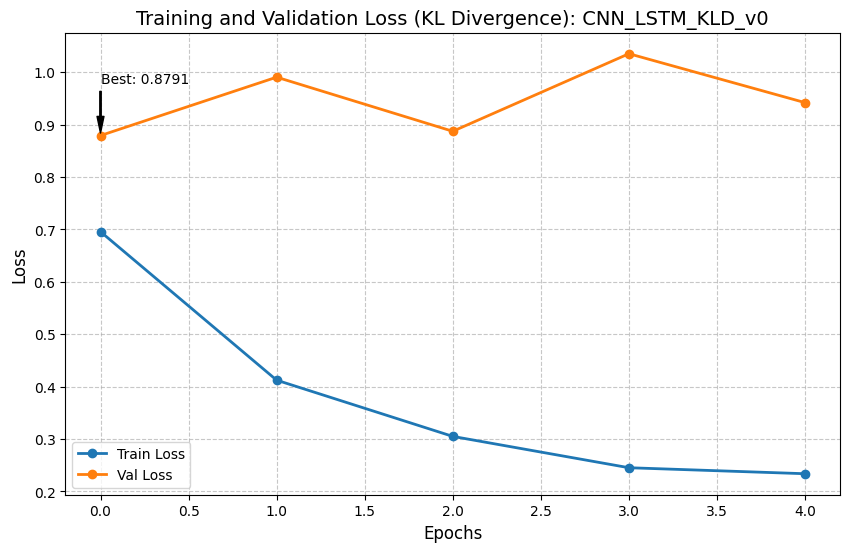

In [12]:
#Training Curve
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure(figsize=(10, 6))

    # Plot Training Loss
    plt.plot(history['train_loss'], label='Train Loss', color='#1f77b4', lw=2, marker='o')
    # Plot Validation Loss
    plt.plot(history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2, marker='o')

    plt.title('Training and Validation Loss (KL Divergence): ' + CFG['model_name'], fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight the best epoch
    best_epoch = np.argmin(history['val_loss'])
    plt.annotate(f'Best: {history["val_loss"][best_epoch]:.4f}',
                 xy=(best_epoch, history['val_loss'][best_epoch]),
                 xytext=(best_epoch, history['val_loss'][best_epoch] + 0.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.show()

plot_history(history)

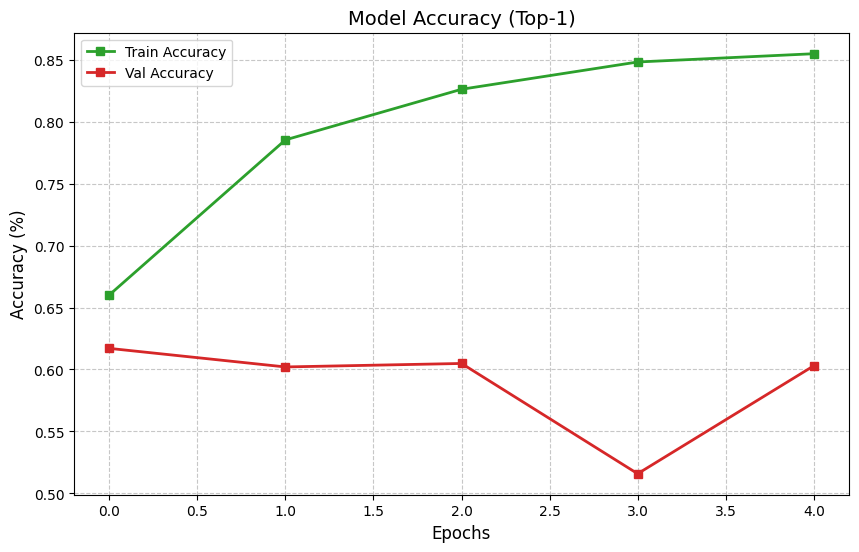

In [13]:
# Accuracy Plot
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history['train_acc'], label='Train Accuracy', color='#2ca02c', lw=2, marker='s')
    plt.plot(history['val_acc'], label='Val Accuracy', color='#d62728', lw=2, marker='s')

    plt.title('Model Accuracy (Top-1)', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# If you've been saving accuracy to history, run this:
plot_accuracy(history)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


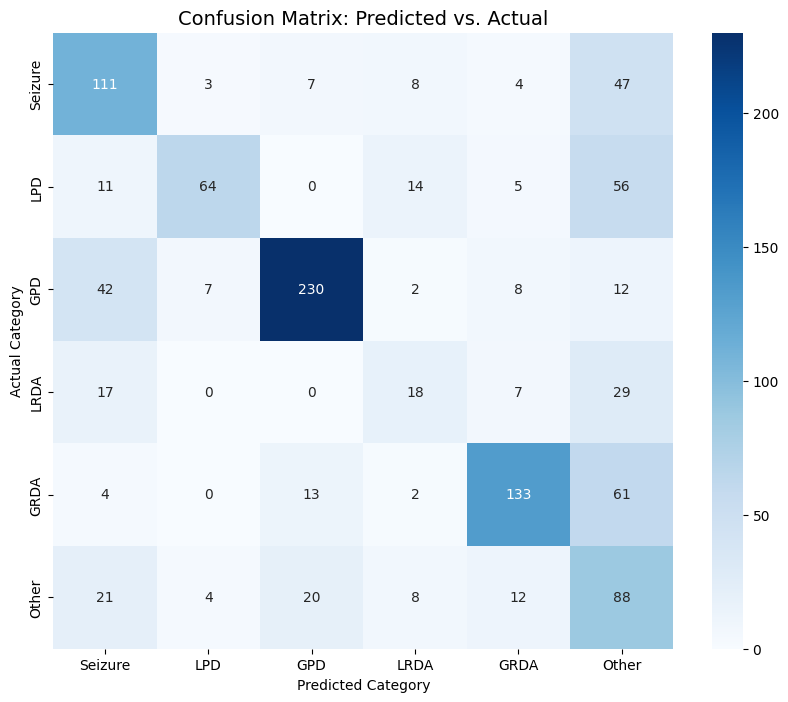

In [14]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    categories = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Get the index of the highest probability
            _, preds = torch.max(outputs, 1)
            _, labels = torch.max(targets, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=categories, yticklabels=categories)
    plt.title('Confusion Matrix: Predicted vs. Actual', fontsize=14)
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.show()

# Run this after training is complete:
plot_confusion_matrix(model, val_loader, device)

In [16]:
#Comparative Metrics
from sklearn.metrics import f1_score, accuracy_score

def calculate_comparative_metrics(model, dataloader, device):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)
            _, labels = torch.max(targets, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    # Calculate key metrics
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro') # Balanced score across all classes

    print(f"--- Comparison Report ---")
    print(f"Top-1 Accuracy: {acc:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")

    return acc, f1

# Run this for your CE model, save the results,
# then run for your KL model and compare.

# Publishing a Report

In [21]:
from sklearn.metrics import classification_report

def generate_final_report(model, dataloader, history, device, filename=f"KL_report_{CFG['model_name']}.png"):
    model.eval()
    all_preds = []
    all_labels = []
    categories = ['Seizure', 'LPD', 'GPD', 'LRDA', 'GRDA', 'Other']

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            _, labels = torch.max(targets, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    fig = plt.figure(figsize=(22, 14), facecolor='white')
    grid = plt.GridSpec(2, 2, wspace=0.3, hspace=0.4)

    # PANEL A & B: Curves (Keep your existing code for ax1 and ax2)
    ax1 = fig.add_subplot(grid[0, 0])
    ax1.plot(history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title('Learning Curve: Loss', fontsize=14, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2 = fig.add_subplot(grid[0, 1])
    ax2.plot(history['train_acc'], label='Train Acc', color='green', marker='s')
    ax2.plot(history['val_acc'], label='Val Acc', color='red', marker='s')
    ax2.set_title('Learning Curve: Accuracy', fontsize=14, fontweight='bold')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    # PANEL C: Confusion Matrix
    ax3 = fig.add_subplot(grid[1, 0])
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories, ax=ax3)
    ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

    # PANEL D: The "Experiment Metadata" Panel
    ax4 = fig.add_subplot(grid[1, 1])
    ax4.axis('off')

    # Format the CFG dictionary for display (removing long paths for neatness)
    cfg_display = {k: v for k, v in CFG.items() if 'path' not in k and 'dir' not in k}
    cfg_text = "\n".join([f"{k}: {v}" for k, v in cfg_display.items()])

    report = classification_report(all_labels, all_preds, target_names=categories)

    # Combine Metrics + Hyperparams
    full_text = f"--- HYPERPARAMETERS ---\n{cfg_text}\n\n"
    full_text += f"--- CLASSIFICATION REPORT ---\n{report}"

    ax4.text(0, 1, full_text, family='monospace', fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.2))

    plt.suptitle(f"CAPSTONE PROJECT: Model Performance Report\nLoss Function: {loss_fn.__class__.__name__}",
                 fontsize=20, fontweight='bold', y=0.98)

    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


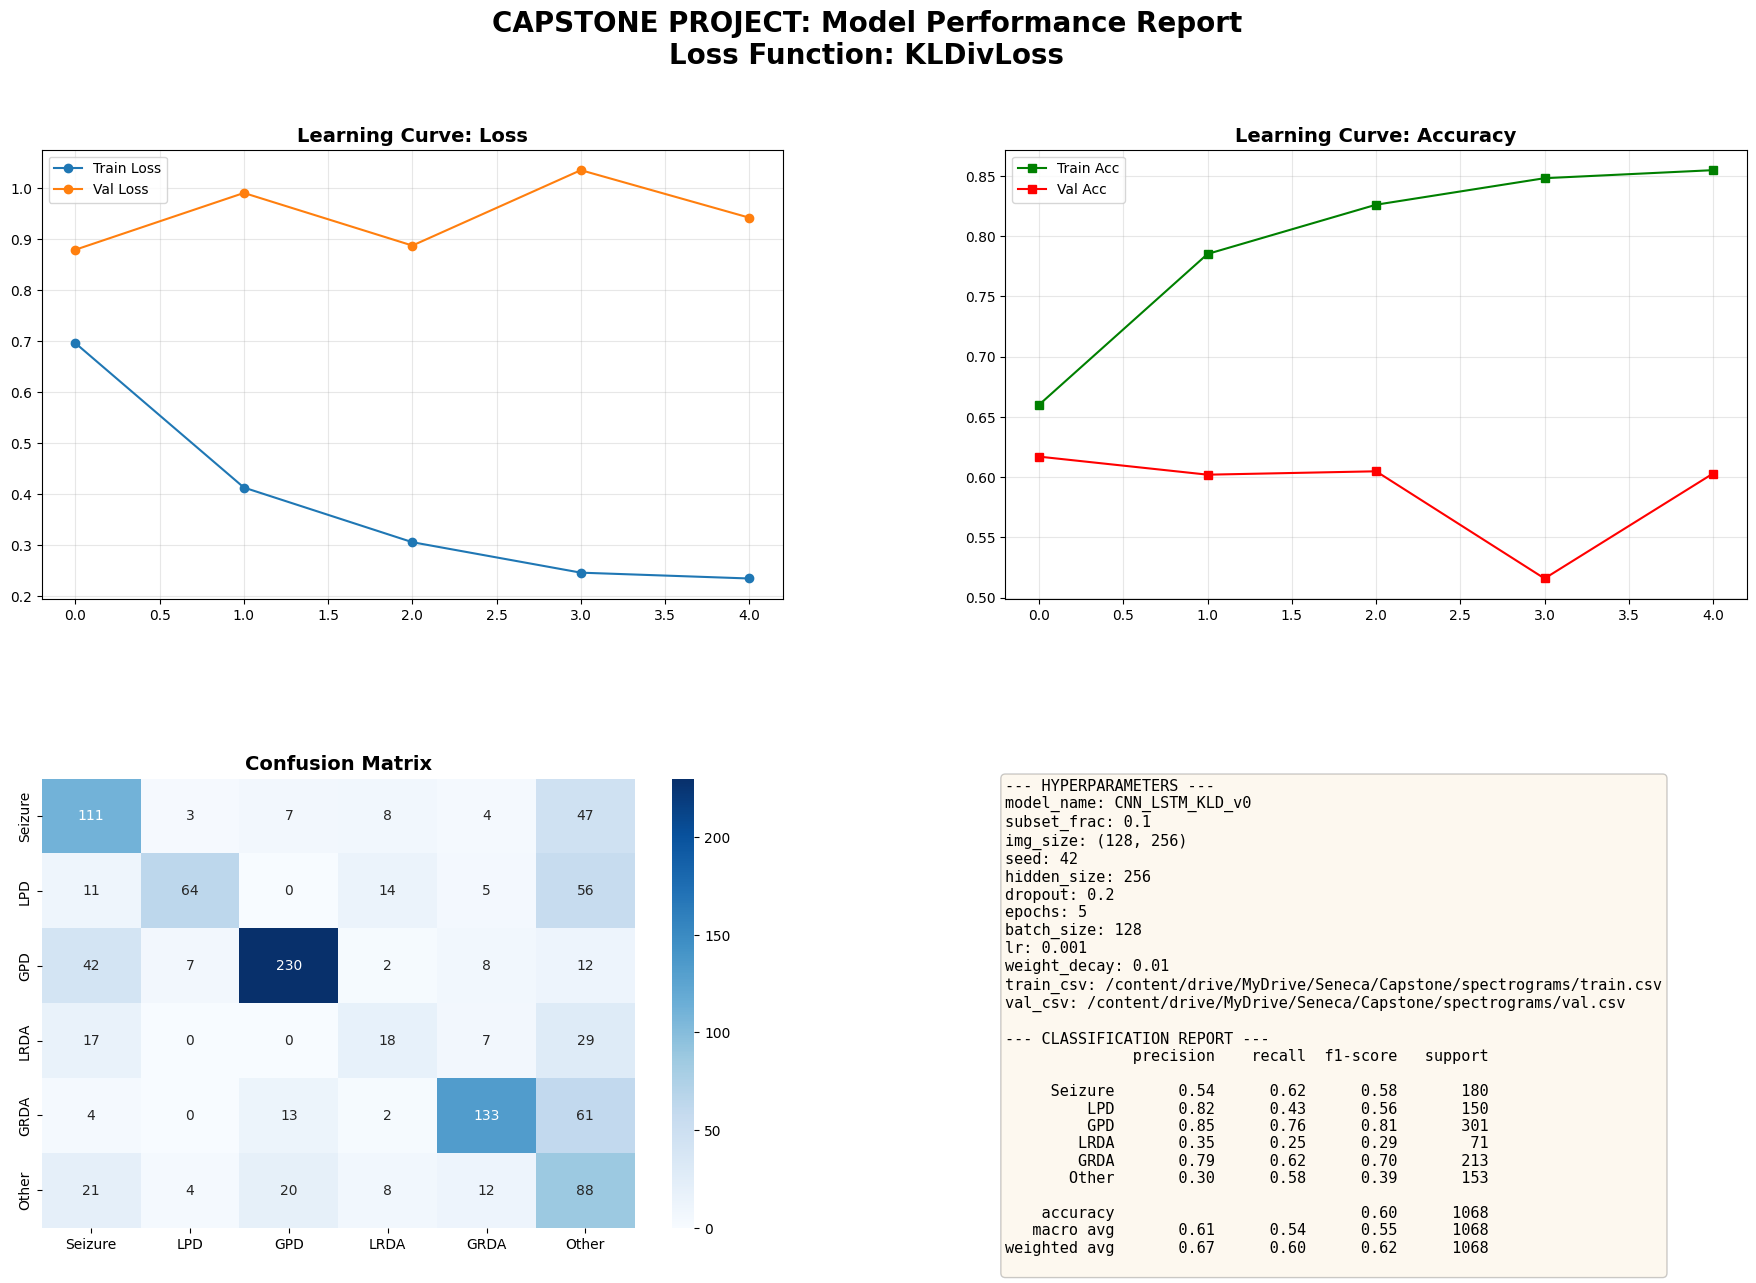

In [22]:
generate_final_report(model, val_loader, history, device)